In this notebook we'll analyze the **North Carolina Voter Registration (NCVR)** dataset and propose a solution for record linkage in this dataset.

Here's a description of the dataset:

The North Carolina Voters dataset is based on real person records from the North-Carolina voter registry and synthetically generated duplicates using the tool GeCo. We consider two configurations with either 5 or 10 sources (here 5) each having 1 million entities; i.e. we process up to 10 million person records. Each source is duplicate free, but 50% of the entities are replicated in all sources without any corruption. Moreover, 25% of entities are corrupted and replicated in all sources, and the remaining 25% are corrupted but present in only some sources. For the generation of corrupted records we applied a moderate corruption rate of 20%, i.e., most attribute values remained unchanged.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Initial EDA

In [2]:
df = pd.read_csv('../data/north_carolina_voters/dataset_1.csv')

/tmp/ipykernel_5442/2178903695.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/north_carolina_voters/dataset_1.csv')


In [3]:
df.head()

,recid,givenname,surname,suburb,postcode
0,7852009,kadelyn,gragnani,waxhaw,28|73
1,3138435,ronel,carter,washington,2788g
2,6117295,jason,roehrig,millers ceeek,286s1
3,6401695,antrea,mure,greensboro,27410
4,5202204,caedar,oliver,jacksonville,28542


In [4]:
df.describe(include='all')

,recid,givenname,surname,suburb,postcode
count,1.000000e+06,999928,999980,999953,999942.0
unique,NaN,76769,134895,16202,5544.0
top,NaN,james,smith,charlotte,28269.0
freq,NaN,18232,12014,79844,6158.0
mean,4.115200e+06,NaN,NaN,NaN,NaN
std,2.376286e+06,NaN,NaN,NaN,NaN
min,1.200000e+01,NaN,NaN,NaN,NaN
25%,2.057178e+06,NaN,NaN,NaN,NaN
50%,4.116210e+06,NaN,NaN,NaN,NaN
75%,6.173061e+06,NaN,NaN,NaN,NaN


In [4]:
df.shape

(1000000, 5)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   recid      1000000 non-null  int64 
 1   givenname  999928 non-null   object
 2   surname    999980 non-null   object
 3   suburb     999953 non-null   object
 4   postcode   999942 non-null   object
dtypes: int64(1), object(4)
memory usage: 38.1+ MB


In [6]:
df.isnull().sum()

recid         0
givenname    72
surname      20
suburb       47
postcode     58
dtype: int64

In [20]:
df['surname'].value_counts()[:1000]

surname
smith        12014
williams      9313
johnson       8526
jones         8299
brown         6933
             ...  
ingle          150
noble          150
self           150
williford      150
parham         150
Name: count, Length: 1000, dtype: int64

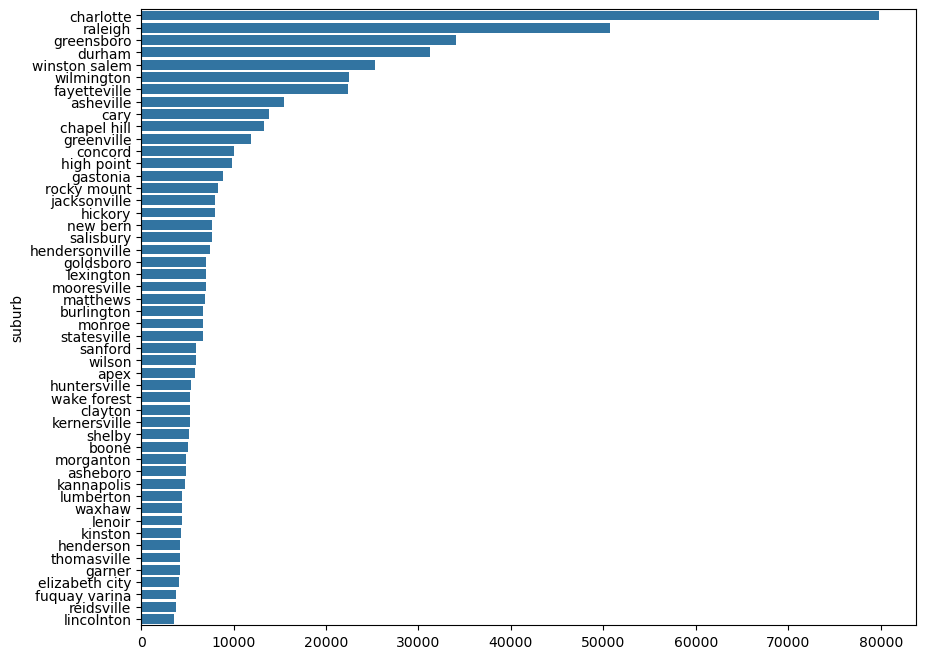

In [25]:
suburbs = df['suburb'].value_counts()[:50]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=suburbs.values, 
    y=suburbs.index)

plt.show()

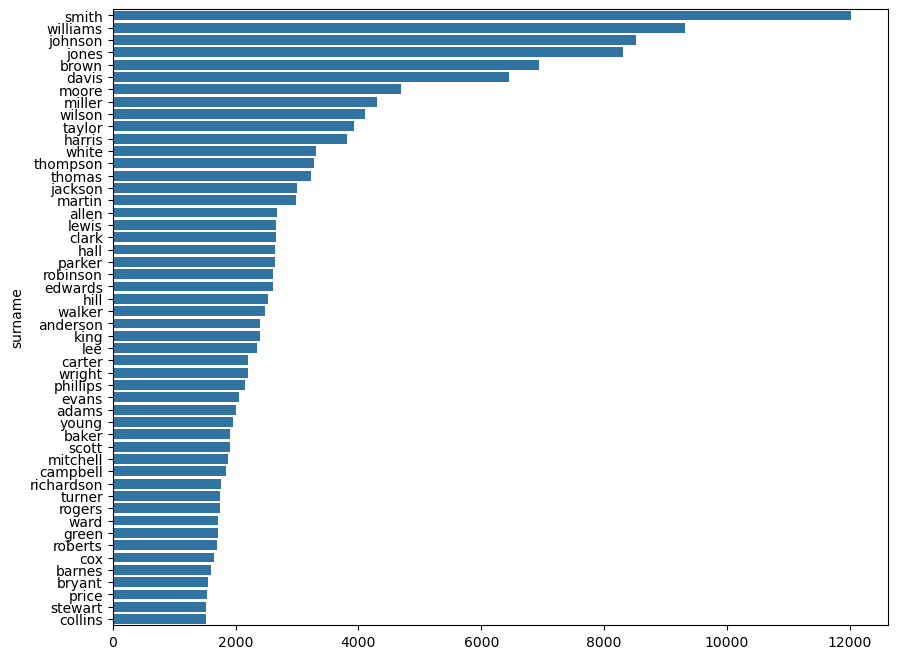

In [30]:
surnames = df['surname'].value_counts()[:50]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=surnames.values, 
    y=surnames.index)

plt.show()

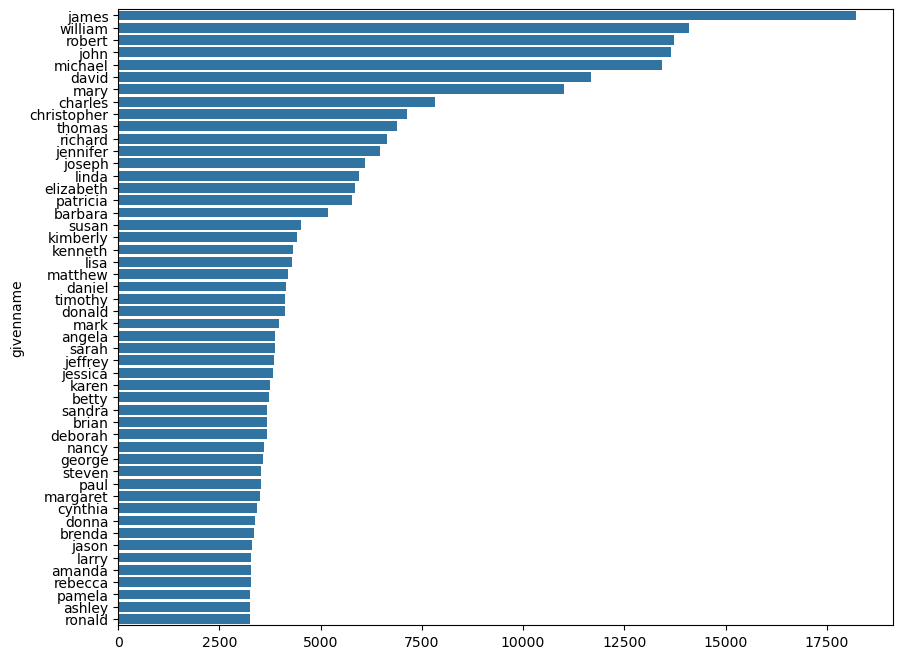

In [33]:
givennames = df['givenname'].value_counts()[:50]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=givennames.values, 
    y=givennames.index)

plt.show()

In [37]:
df['postcode'].value_counts()[:10]

postcode
28269.0    6158
28277.0    5963
27858.0    5717
27410.0    5646
27707.0    5530
27610.0    5506
27406.0    5478
27713.0    5384
27834.0    4977
28078.0    4887
Name: count, dtype: int64

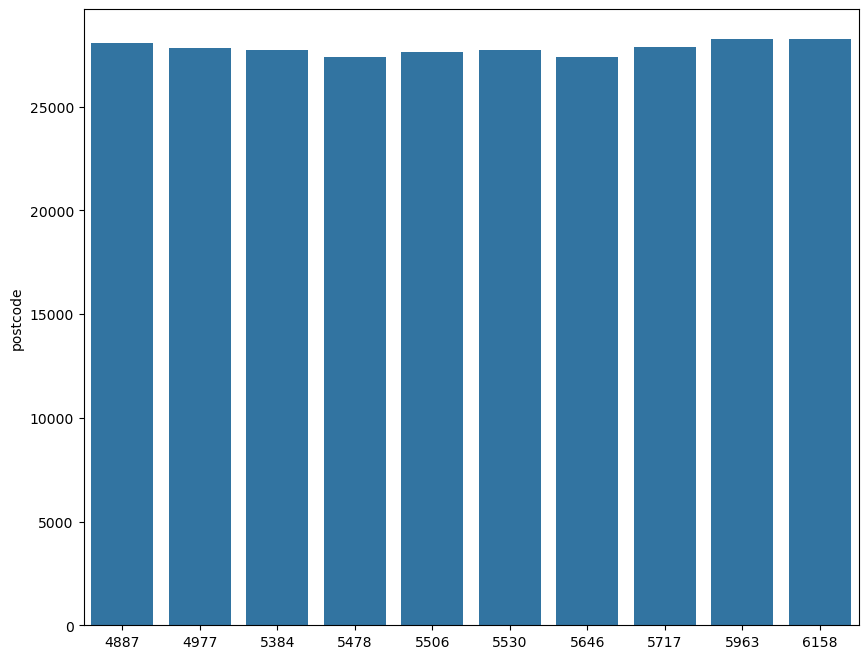

In [35]:
postcodes = df['postcode'].value_counts()[:10]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=postcodes.values, 
    y=postcodes.index)

plt.show()

# Basic pandas operations

In [6]:
# Employees DataFrame
employees_data = {
    'emp_id': [101, 102, 103, 104, 105, 106, 107, 108],
    'first_name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi'],
    'salary': [70000, 85000, 60000, 95000, 110000, 55000, np.nan, 72000],
    'dept_id': [1, 2, 1, 2, 3, 3, 1, 4]
}
employees = pd.DataFrame(employees_data)

# Departments DataFrame
departments_data = {
    'dept_id': [1, 2, 3, 5],
    'dept_name': ['Engineering', 'Sales', 'Marketing', 'HR']
}
departments = pd.DataFrame(departments_data)

In [13]:
employees[['emp_id', 'salary']].rename(columns={'emp_id': 'id'}).head(3)

,id,salary
0,101,70000.0
1,102,85000.0
2,103,60000.0


In [20]:
employees.query(
    'salary.between(60000, 90000) and dept_id.isin([1, 3])'
)[['first_name', 'dept_id']]

,first_name,dept_id
0,Alice,1
2,Charlie,1


In [22]:
result = (
    employees
    .dropna(subset='salary')
    .groupby('dept_id')
    .agg(
        num_employees=('emp_id', 'count'),
        avg_salary=('salary', 'mean')
    )
    .rename_axis('dept_id')
    .reset_index()
    .query('num_employees > 1')
    .sort_values('avg_salary', ascending=False)
)
print(result)

   dept_id  num_employees  avg_salary
1        2              2     90000.0
2        3              2     82500.0
0        1              2     65000.0


In [23]:
result = pd.merge(
    employees,
    departments,
    on='dept_id',
    how='left'
)

result = result[['first_name', 'salary', 'dept_name']]

print(result)

  first_name    salary    dept_name
0      Alice   70000.0  Engineering
1        Bob   85000.0        Sales
2    Charlie   60000.0  Engineering
3      David   95000.0        Sales
4        Eve  110000.0    Marketing
5      Frank   55000.0    Marketing
6      Grace       NaN  Engineering
7      Heidi   72000.0          NaN


In [27]:
from sys import api_version


merged_df = pd.merge(employees, departments, on='dept_id', how='inner')

final_result = (
    merged_df
    .query("first_name < 'F' and salary.notna()")
    .groupby("dept_name")
    .agg(
        employee_count=('emp_id', 'count'),
        average_salary=('salary', lambda s : round(s.mean(), 0))
    )
    .query("employee_count >= 2")
    .sort_values('average_salary', ascending=False)
    .head(1)
)

print(final_result)

           employee_count  average_salary
dept_name                                
Sales                   2         90000.0


# Basic pyplot/seaborn plots
